In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [3]:
# Load the GED dataset
print("Loading GED dataset...")
df = pd.read_csv('GEDEvent_v25_1.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()

Loading GED dataset...


C:\Users\moheb\AppData\Local\Temp\ipykernel_24496\3268404181.py:3: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('GEDEvent_v25_1.csv')


Dataset shape: (385918, 49)

Column names: ['id', 'relid', 'year', 'active_year', 'code_status', 'type_of_violence', 'conflict_dset_id', 'conflict_new_id', 'conflict_name', 'dyad_dset_id', 'dyad_new_id', 'dyad_name', 'side_a_dset_id', 'side_a_new_id', 'side_a', 'side_b_dset_id', 'side_b_new_id', 'side_b', 'number_of_sources', 'source_article', 'source_office', 'source_date', 'source_headline', 'source_original', 'where_prec', 'where_coordinates', 'where_description', 'adm_1', 'adm_2', 'latitude', 'longitude', 'geom_wkt', 'priogrid_gid', 'country', 'country_id', 'region', 'event_clarity', 'date_prec', 'date_start', 'date_end', 'deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best', 'high', 'low', 'gwnoa', 'gwnob']

First few rows:


,id,relid,year,active_year,code_status,type_of_violence,conflict_dset_id,conflict_new_id,conflict_name,dyad_dset_id,...,date_end,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnoa,gwnob
0,244657,IRQ-2017-1-524-322,2017,True,Clear,1,259,259,Iraq: Government,524,...,2017-07-31,0,4,0,2,6,6,6,645,NaN
1,412700,IRQ-2021-1-524-145,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-26,13,1,141,28,183,184,171,645,NaN
2,413023,IRQ-2021-1-524-143,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-28,0,2,0,0,2,3,0,645,NaN
3,412909,IRQ-2021-1-524-144,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-29,0,0,10,0,10,10,9,645,NaN
4,132140,AFG-1989-1-411-2,1989,True,Clear,1,333,333,Afghanistan: Government,724,...,1989-01-13,6,0,0,0,6,6,6,700,NaN


In [4]:
# Examine unique countries to find exact names
unique_countries = df['country'].unique()
print(f"Total unique countries: {len(unique_countries)}")

# Look for Syria, Yemen, and Myanmar variants
target_countries = []
for country in unique_countries:
    if any(keyword in country.lower() for keyword in ['syria', 'yemen', 'myanmar', 'burma']):
        target_countries.append(country)
        print(f"Found: {country}")

print(f"\nTarget countries found: {target_countries}")

Total unique countries: 124
Found: Myanmar (Burma)
Found: Syria
Found: Yemen (North Yemen)

Target countries found: ['Myanmar (Burma)', 'Syria', 'Yemen (North Yemen)']


In [5]:
# Check year range in dataset
print(f"Year range in dataset: {df['year'].min()} - {df['year'].max()}")
print(f"Years available: {sorted(df['year'].unique())}")

# Check what columns contain casualty information
casualty_cols = [col for col in df.columns if 'death' in col.lower() or 'casualt' in col.lower() or col in ['best', 'high', 'low']]
print(f"\nCasualty-related columns: {casualty_cols}")

# Check some sample values for casualties
print(f"\nSample casualty data:")
for col in ['deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best']:
    if col in df.columns:
        print(f"{col}: {df[col].describe()}")

Year range in dataset: 1989 - 2024
Years available: [1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

Casualty-related columns: ['deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best', 'high', 'low']

Sample casualty data:
deaths_a: count    385918.000000
mean          2.470660
std         254.720238
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      121848.000000
Name: deaths_a, dtype: float64
deaths_b: count    385918.000000
mean          2.245581
std          53.764628
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max       19874.000000
Name: deaths_b, dtype: float64
deaths_civilians: count    385918.000000
mean          3.819710
std         178.402817
min           0.000000
25%           0.000000
50%         

In [10]:
# Filter data for target countries and years (2011-2024) - EXCLUDE Syria
target_countries = ['Myanmar (Burma)', 'Yemen (North Yemen)']  # Removed Syria
filtered_df = df[
    (df['country'].isin(target_countries)) & 
    (df['year'] >= 2011) & 
    (df['year'] <= 2024)
].copy()

print(f"Filtered dataset shape: {filtered_df.shape}")
print(f"\nEvents per country:")
country_counts = filtered_df['country'].value_counts()
print(country_counts)

print(f"\nEvents per year:")
year_counts = filtered_df['year'].value_counts().sort_index()
print(year_counts)

Filtered dataset shape: (11987, 49)

Events per country:
country
Myanmar (Burma)        6689
Yemen (North Yemen)    5298
Name: count, dtype: int64

Events per year:
year
2011     484
2012     330
2013     212
2014     316
2015     803
2016     400
2017     485
2018     458
2019     452
2020     734
2021    1625
2022    2004
2023    2404
2024    1280
Name: count, dtype: int64


In [11]:
# Aggregate data by country and year
yearly_stats = filtered_df.groupby(['country', 'year']).agg({
    'best': 'sum',          # Total casualties (deaths)
    'id': 'count'           # Number of events
}).reset_index()

# Rename columns for clarity
yearly_stats.rename(columns={'best': 'total_deaths', 'id': 'num_events'}, inplace=True)

# Calculate average casualties per event
yearly_stats['avg_casualties_per_event'] = yearly_stats['total_deaths'] / yearly_stats['num_events']

print("Yearly statistics sample:")
print(yearly_stats.head(10))

# Create simplified country names for plotting (remove Syria)
country_name_mapping = {
    'Myanmar (Burma)': 'Myanmar',
    'Yemen (North Yemen)': 'Yemen'
}

yearly_stats['country_simple'] = yearly_stats['country'].map(country_name_mapping)

print(f"\nData summary:")
summary = yearly_stats.groupby('country_simple').agg({
    'total_deaths': 'sum',
    'num_events': 'sum',
    'avg_casualties_per_event': 'mean'
}).round(2)
print(summary)

Yearly statistics sample:
           country  year  total_deaths  num_events  avg_casualties_per_event
0  Myanmar (Burma)  2011           811         265                  3.060377
1  Myanmar (Burma)  2012           971          77                 12.610390
2  Myanmar (Burma)  2013           358          86                  4.162791
3  Myanmar (Burma)  2014           256          35                  7.314286
4  Myanmar (Burma)  2015           705         198                  3.560606
5  Myanmar (Burma)  2016           183          57                  3.210526
6  Myanmar (Burma)  2017          2395          88                 27.215909
7  Myanmar (Burma)  2018           122          71                  1.718310
8  Myanmar (Burma)  2019           587         148                  3.966216
9  Myanmar (Burma)  2020           207          77                  2.688312

Data summary:
                total_deaths  num_events  avg_casualties_per_event
country_simple                               

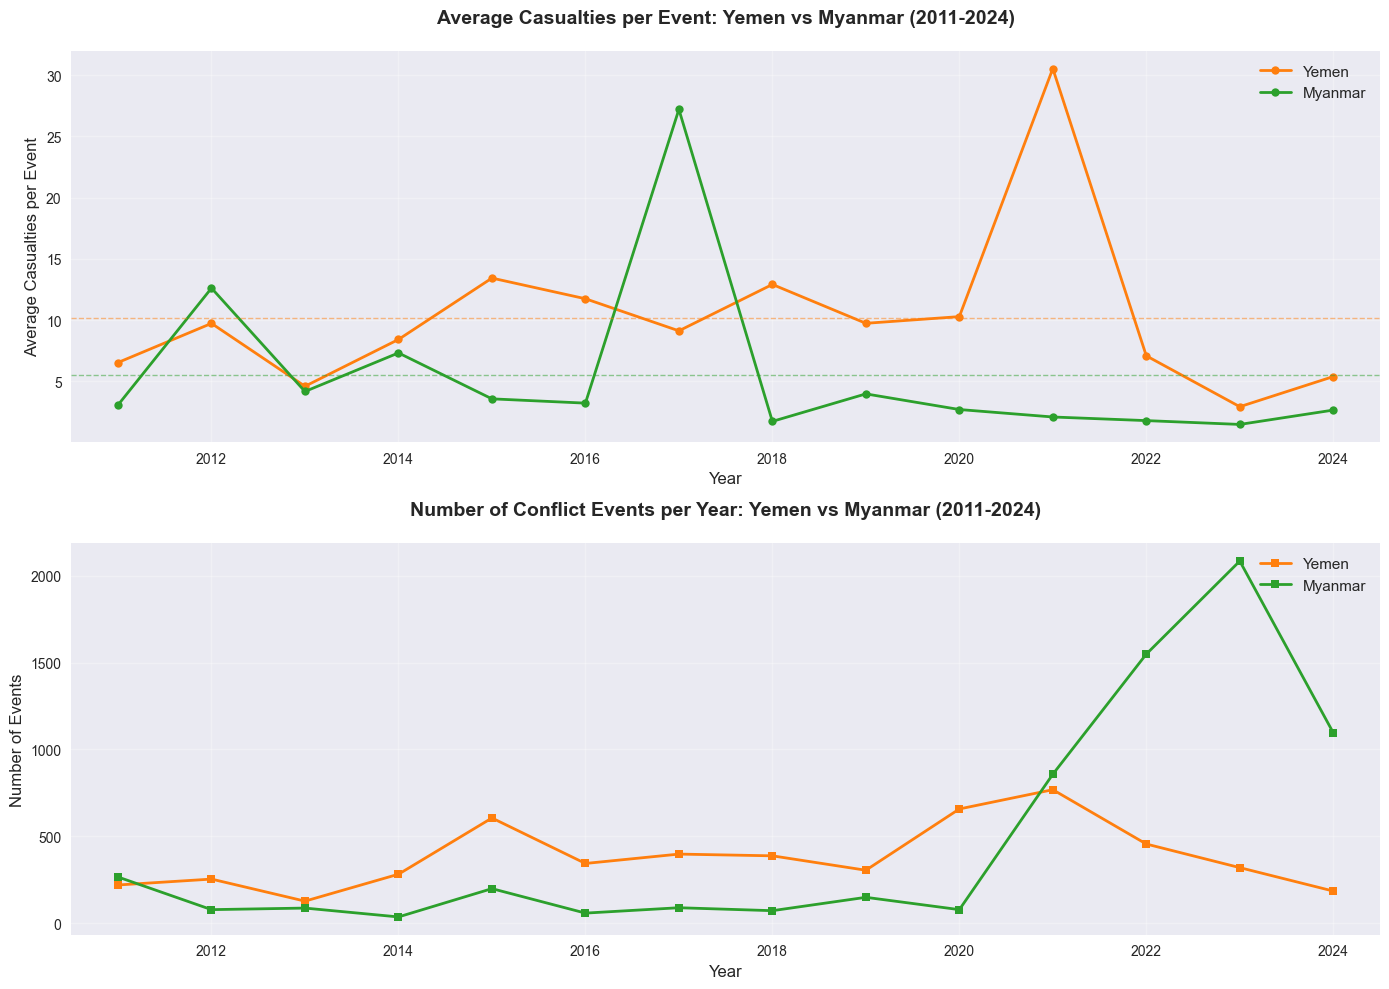


Key Statistics (2011-2024) - Yemen vs Myanmar:

Yemen:
  Total Deaths: 65,918
  Total Events: 5,298
  Overall Avg Casualties/Event: 12.44
  Peak Avg Casualties/Event: 30.55 (in 2021)

Myanmar:
  Total Deaths: 17,098
  Total Events: 6,689
  Overall Avg Casualties/Event: 2.56
  Peak Avg Casualties/Event: 27.22 (in 2017)


In [12]:
# Create the timeline visualization (Yemen vs Myanmar only)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Define colors for consistency (remove Syria)
colors = {'Yemen': '#ff7f0e', 'Myanmar': '#2ca02c'}

# Plot 1: Average Casualties per Event (normalized)
for country in ['Yemen', 'Myanmar']:
    country_data = yearly_stats[yearly_stats['country_simple'] == country]
    ax1.plot(country_data['year'], country_data['avg_casualties_per_event'], 
            marker='o', linewidth=2, markersize=6,
            label=country, color=colors[country])

ax1.set_title('Average Casualties per Event: Yemen vs Myanmar (2011-2024)', 
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Average Casualties per Event', fontsize=12)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(2010.5, 2024.5)

# Add horizontal reference lines for overall averages
for country in ['Yemen', 'Myanmar']:
    country_data = yearly_stats[yearly_stats['country_simple'] == country]
    overall_avg = country_data['avg_casualties_per_event'].mean()
    ax1.axhline(y=overall_avg, color=colors[country], linestyle='--', alpha=0.5, linewidth=1)

# Plot 2: Number of Conflict Events per Year
for country in ['Yemen', 'Myanmar']:
    country_data = yearly_stats[yearly_stats['country_simple'] == country]
    ax2.plot(country_data['year'], country_data['num_events'], 
            marker='s', linewidth=2, markersize=6,
            label=country, color=colors[country])

ax2.set_title('Number of Conflict Events per Year: Yemen vs Myanmar (2011-2024)', 
              fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Number of Events', fontsize=12)
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(2010.5, 2024.5)

# Adjust layout and show
plt.tight_layout()
plt.show()

# Print some key statistics (without Syria)
print("\nKey Statistics (2011-2024) - Yemen vs Myanmar:")
print("="*60)
for country in ['Yemen', 'Myanmar']:
    country_data = yearly_stats[yearly_stats['country_simple'] == country]
    total_deaths = country_data['total_deaths'].sum()
    total_events = country_data['num_events'].sum()
    avg_casualties_overall = total_deaths / total_events if total_events > 0 else 0
    peak_year_avg = country_data.loc[country_data['avg_casualties_per_event'].idxmax(), 'year']
    peak_avg = country_data['avg_casualties_per_event'].max()
    
    print(f"\n{country}:")
    print(f"  Total Deaths: {total_deaths:,}")
    print(f"  Total Events: {total_events:,}")
    print(f"  Overall Avg Casualties/Event: {avg_casualties_overall:.2f}")
    print(f"  Peak Avg Casualties/Event: {peak_avg:.2f} (in {peak_year_avg})")

# Analysis Summary: Normalized Conflict Analysis (2011-2024)

## Key Findings: Yemen vs Myanmar

### Yemen (2011-2024)
- **Total Deaths**: 65,918
- **Total Events**: 5,298
- **Overall Avg Casualties/Event**: 12.44
- **Peak Average**: 30.55 casualties/event (in 2021)
- **Pattern**: Higher intensity conflicts with notable spike in 2021, showing more lethal individual events

### Myanmar (2011-2024) 
- **Total Deaths**: 17,098
- **Total Events**: 6,689
- **Overall Avg Casualties/Event**: 2.56
- **Peak Average**: 27.22 casualties/event (in 2017)
- **Pattern**: More frequent but generally lower-intensity events, with notable spike in 2017

## Observations:
1. **Yemen** shows significantly higher **lethality per event** (12.44 avg vs 2.56 avg)
2. **Myanmar** has more **frequent events** but lower casualty rates per incident
3. **Yemen's 2021 spike** indicates major escalation in conflict intensity
4. **Myanmar's 2017 peak** suggests a significant violent episode (possibly related to Rohingya crisis)
5. Both countries show different conflict dynamics:
   - **Yemen**: Fewer but deadlier conflicts
   - **Myanmar**: More numerous but less lethal incidents

## Methodology:
- Normalized casualties per event calculated as: Total Deaths ÷ Number of Events
- Analysis focused on comparing conflict intensity rather than absolute numbers
- Reference lines show overall country averages for context

In [13]:
# Calculate total casualties for Yemen and Myanmar during 2021-2024
print("Total Casualties (2021-2024):")
print("="*40)

# Filter data for 2021-2024 period
recent_data = yearly_stats[yearly_stats['year'].between(2021, 2024)]

for country in ['Yemen', 'Myanmar']:
    country_data = recent_data[recent_data['country_simple'] == country]
    total_deaths_recent = country_data['total_deaths'].sum()
    total_events_recent = country_data['num_events'].sum()
    
    print(f"\n{country} (2021-2024):")
    print(f"  Total Deaths: {total_deaths_recent:,}")
    print(f"  Total Events: {total_events_recent:,}")
    if total_events_recent > 0:
        avg_per_event = total_deaths_recent / total_events_recent
        print(f"  Avg Deaths/Event: {avg_per_event:.2f}")

# Show year-by-year breakdown
print(f"\n\nYear-by-Year Breakdown (2021-2024):")
print("="*50)

for year in range(2021, 2025):
    year_data = recent_data[recent_data['year'] == year]
    print(f"\n{year}:")
    for country in ['Yemen', 'Myanmar']:
        country_year = year_data[year_data['country_simple'] == country]
        if not country_year.empty:
            deaths = country_year['total_deaths'].iloc[0]
            events = country_year['num_events'].iloc[0]
            print(f"  {country}: {deaths:,} deaths ({events:,} events)")
        else:
            print(f"  {country}: 0 deaths (0 events)")

# Calculate percentage of total casualties in recent period
print(f"\n\nRecent Period Analysis:")
print("="*30)
for country in ['Yemen', 'Myanmar']:
    total_all_years = yearly_stats[yearly_stats['country_simple'] == country]['total_deaths'].sum()
    total_recent = recent_data[recent_data['country_simple'] == country]['total_deaths'].sum()
    percentage = (total_recent / total_all_years * 100) if total_all_years > 0 else 0
    
    print(f"\n{country}:")
    print(f"  2021-2024: {total_recent:,} deaths")
    print(f"  2011-2024: {total_all_years:,} deaths") 
    print(f"  Recent % of total: {percentage:.1f}%")

Total Casualties (2021-2024):

Yemen (2021-2024):
  Total Deaths: 28,604
  Total Events: 1,726
  Avg Deaths/Event: 16.57

Myanmar (2021-2024):
  Total Deaths: 10,503
  Total Events: 5,587
  Avg Deaths/Event: 1.88


Year-by-Year Breakdown (2021-2024):

2021:
  Yemen: 23,463 deaths (768 events)
  Myanmar: 1,781 deaths (857 events)

2022:
  Yemen: 3,220 deaths (455 events)
  Myanmar: 2,761 deaths (1,549 events)

2023:
  Yemen: 931 deaths (319 events)
  Myanmar: 3,065 deaths (2,085 events)

2024:
  Yemen: 990 deaths (184 events)
  Myanmar: 2,896 deaths (1,096 events)


Recent Period Analysis:

Yemen:
  2021-2024: 28,604 deaths
  2011-2024: 65,918 deaths
  Recent % of total: 43.4%

Myanmar:
  2021-2024: 10,503 deaths
  2011-2024: 17,098 deaths
  Recent % of total: 61.4%


In [15]:
# Create CSV file for the Yemen-Myanmar timeline data
# Note: Data is yearly, not monthly as requested, since that's what's available in the dataset

# Prepare the data for export - pivot to have countries as columns
timeline_export = yearly_stats.pivot_table(
    index='year', 
    columns='country_simple', 
    values=['total_deaths', 'num_events', 'avg_casualties_per_event'],
    fill_value=0
).reset_index()

# Flatten column names
timeline_export.columns = [f'{col[1]}_{col[0]}' if col[1] else col[0] 
                          for col in timeline_export.columns]

# Rename the year column back
timeline_export.rename(columns={'_year': 'year'}, inplace=True)

# Reorder columns for better readability
column_order = ['year', 
                'Yemen_total_deaths', 'Myanmar_total_deaths',
                'Yemen_num_events', 'Myanmar_num_events', 
                'Yemen_avg_casualties_per_event', 'Myanmar_avg_casualties_per_event']

timeline_export = timeline_export[column_order]

# Save to CSV
filename = 'Yemen-Myanmar_yearly_timeline.csv'
timeline_export.to_csv(filename, index=False)

print(f"Timeline data exported to: {filename}")
print(f"File contains yearly data from {timeline_export['year'].min()} to {timeline_export['year'].max()}")
print(f"\nDataset shape: {timeline_export.shape}")
print(f"\nColumns:")
for col in timeline_export.columns:
    print(f"  - {col}")

print(f"\nFirst few rows:")
print(timeline_export.head())

print(f"\nLast few rows:")
print(timeline_export.tail())

Timeline data exported to: Yemen-Myanmar_yearly_timeline.csv
File contains yearly data from 2011 to 2024

Dataset shape: (14, 7)

Columns:
  - year
  - Yemen_total_deaths
  - Myanmar_total_deaths
  - Yemen_num_events
  - Myanmar_num_events
  - Yemen_avg_casualties_per_event
  - Myanmar_avg_casualties_per_event

First few rows:
   year  Yemen_total_deaths  Myanmar_total_deaths  Yemen_num_events   
0  2011                1430                   811               219  \
1  2012                2461                   971               253   
2  2013                 578                   358               126   
3  2014                2364                   256               281   
4  2015                8125                   705               605   

   Myanmar_num_events  Yemen_avg_casualties_per_event   
0                 265                        6.529680  \
1                  77                        9.727273   
2                  86                        4.587302   
3               